## Decision Trees

In this notebook you will experiment with different tree based algorithms on some different datasets. You will need to:


Create 3 models:

1. DecisionTreeClassifier()
2. RandomForestClassifier()
3. XGBClassifier()

These will be inserted into the dictionaries below for comparison.

You will also get a feeling for the different hyperparameters for each of these methods. Along with this, I want you to get used to reading the documentation of the different APIs. I will provide you with links.

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

https://xgboost.readthedocs.io/en/latest/python/python_api.html#module-xgboost.training



In [1]:
%pwd

'/home/djanuskiewicz/AI4Fusion_2026/Project/XGBoost'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_classification,make_moons
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_circles
import time

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [13]:
df = pd.read_csv('../data/cmod_clean_200ms.csv')

,Unnamed: 0,shot,time,a_minor,beta_n,beta_p,bt,chisq,dbetap_dt,dip_dt,...,v_loop,v_loop_efit,v_surf,v_z,wmhd,z_error,z_prog,z_times_v_z,zcur,disruptive
526246,940515,1140211006,1.40,0.224153,0.339973,0.154231,5.386440,16.781702,-0.331477,1.168480e+06,...,1.201284,1.376992,1.444858,0.453785,42894.128906,0.001341,0.009012,0.004698,0.010353,0
526247,940516,1140211006,1.42,0.223878,0.299285,0.135459,5.383023,16.955473,-0.412427,1.166281e+06,...,1.849325,1.403160,1.442194,2.715747,37786.804688,0.001066,0.009013,0.027374,0.010080,0
526248,940517,1140211006,1.44,0.223053,0.303324,0.137733,5.381559,17.233974,0.174302,3.947276e+05,...,1.362813,1.478647,1.366938,-1.838071,38398.691406,-0.000196,0.009014,-0.016207,0.008818,0
526249,940518,1140211006,1.46,0.222101,0.311538,0.142431,5.382535,17.893890,-0.054488,1.172580e+06,...,1.213075,1.496440,1.393111,-3.417095,39519.207031,0.000273,0.009016,-0.031741,0.009288,0
526250,940519,1140211006,1.48,0.221867,0.296491,0.135554,5.384487,17.898066,-0.081536,2.661531e+03,...,1.475937,1.348752,1.368059,3.174205,37524.597656,0.000014,0.009017,0.028663,0.009030,0


In [15]:
df.tail()

,Unnamed: 0,shot,time,a_minor,beta_n,beta_p,bt,chisq,dbetap_dt,dip_dt,...,v_loop,v_loop_efit,v_surf,v_z,wmhd,z_error,z_prog,z_times_v_z,zcur,disruptive
526246,940515,1140211006,1.40,0.224153,0.339973,0.154231,5.386440,16.781702,-0.331477,1.168480e+06,...,1.201284,1.376992,1.444858,0.453785,42894.128906,0.001341,0.009012,0.004698,0.010353,0
526247,940516,1140211006,1.42,0.223878,0.299285,0.135459,5.383023,16.955473,-0.412427,1.166281e+06,...,1.849325,1.403160,1.442194,2.715747,37786.804688,0.001066,0.009013,0.027374,0.010080,0
526248,940517,1140211006,1.44,0.223053,0.303324,0.137733,5.381559,17.233974,0.174302,3.947276e+05,...,1.362813,1.478647,1.366938,-1.838071,38398.691406,-0.000196,0.009014,-0.016207,0.008818,0
526249,940518,1140211006,1.46,0.222101,0.311538,0.142431,5.382535,17.893890,-0.054488,1.172580e+06,...,1.213075,1.496440,1.393111,-3.417095,39519.207031,0.000273,0.009016,-0.031741,0.009288,0
526250,940519,1140211006,1.48,0.221867,0.296491,0.135554,5.384487,17.898066,-0.081536,2.661531e+03,...,1.475937,1.348752,1.368059,3.174205,37524.597656,0.000014,0.009017,0.028663,0.009030,0


array([[<Axes: title={'center': 'a_minor'}>,
        <Axes: title={'center': 'beta_n'}>,
        <Axes: title={'center': 'beta_p'}>,
        <Axes: title={'center': 'chisq'}>,
        <Axes: title={'center': 'dbetap_dt'}>,
        <Axes: title={'center': 'dip_dt'}>],
       [<Axes: title={'center': 'dip_smoothed'}>,
        <Axes: title={'center': 'dipprog_dt'}>,
        <Axes: title={'center': 'dli_dt'}>,
        <Axes: title={'center': 'dn_dt'}>,
        <Axes: title={'center': 'dwmhd_dt'}>,
        <Axes: title={'center': 'greenwald_fraction'}>],
       [<Axes: title={'center': 'ip'}>,
        <Axes: title={'center': 'ip_error'}>,
        <Axes: title={'center': 'ip_prog'}>,
        <Axes: title={'center': 'kappa'}>,
        <Axes: title={'center': 'kappa_area'}>,
        <Axes: title={'center': 'li'}>],
       [<Axes: title={'center': 'lower_gap'}>,
        <Axes: title={'center': 'n_e'}>,
        <Axes: title={'center': 'p_icrf'}>,
        <Axes: title={'center': 'p_input'}>,
    

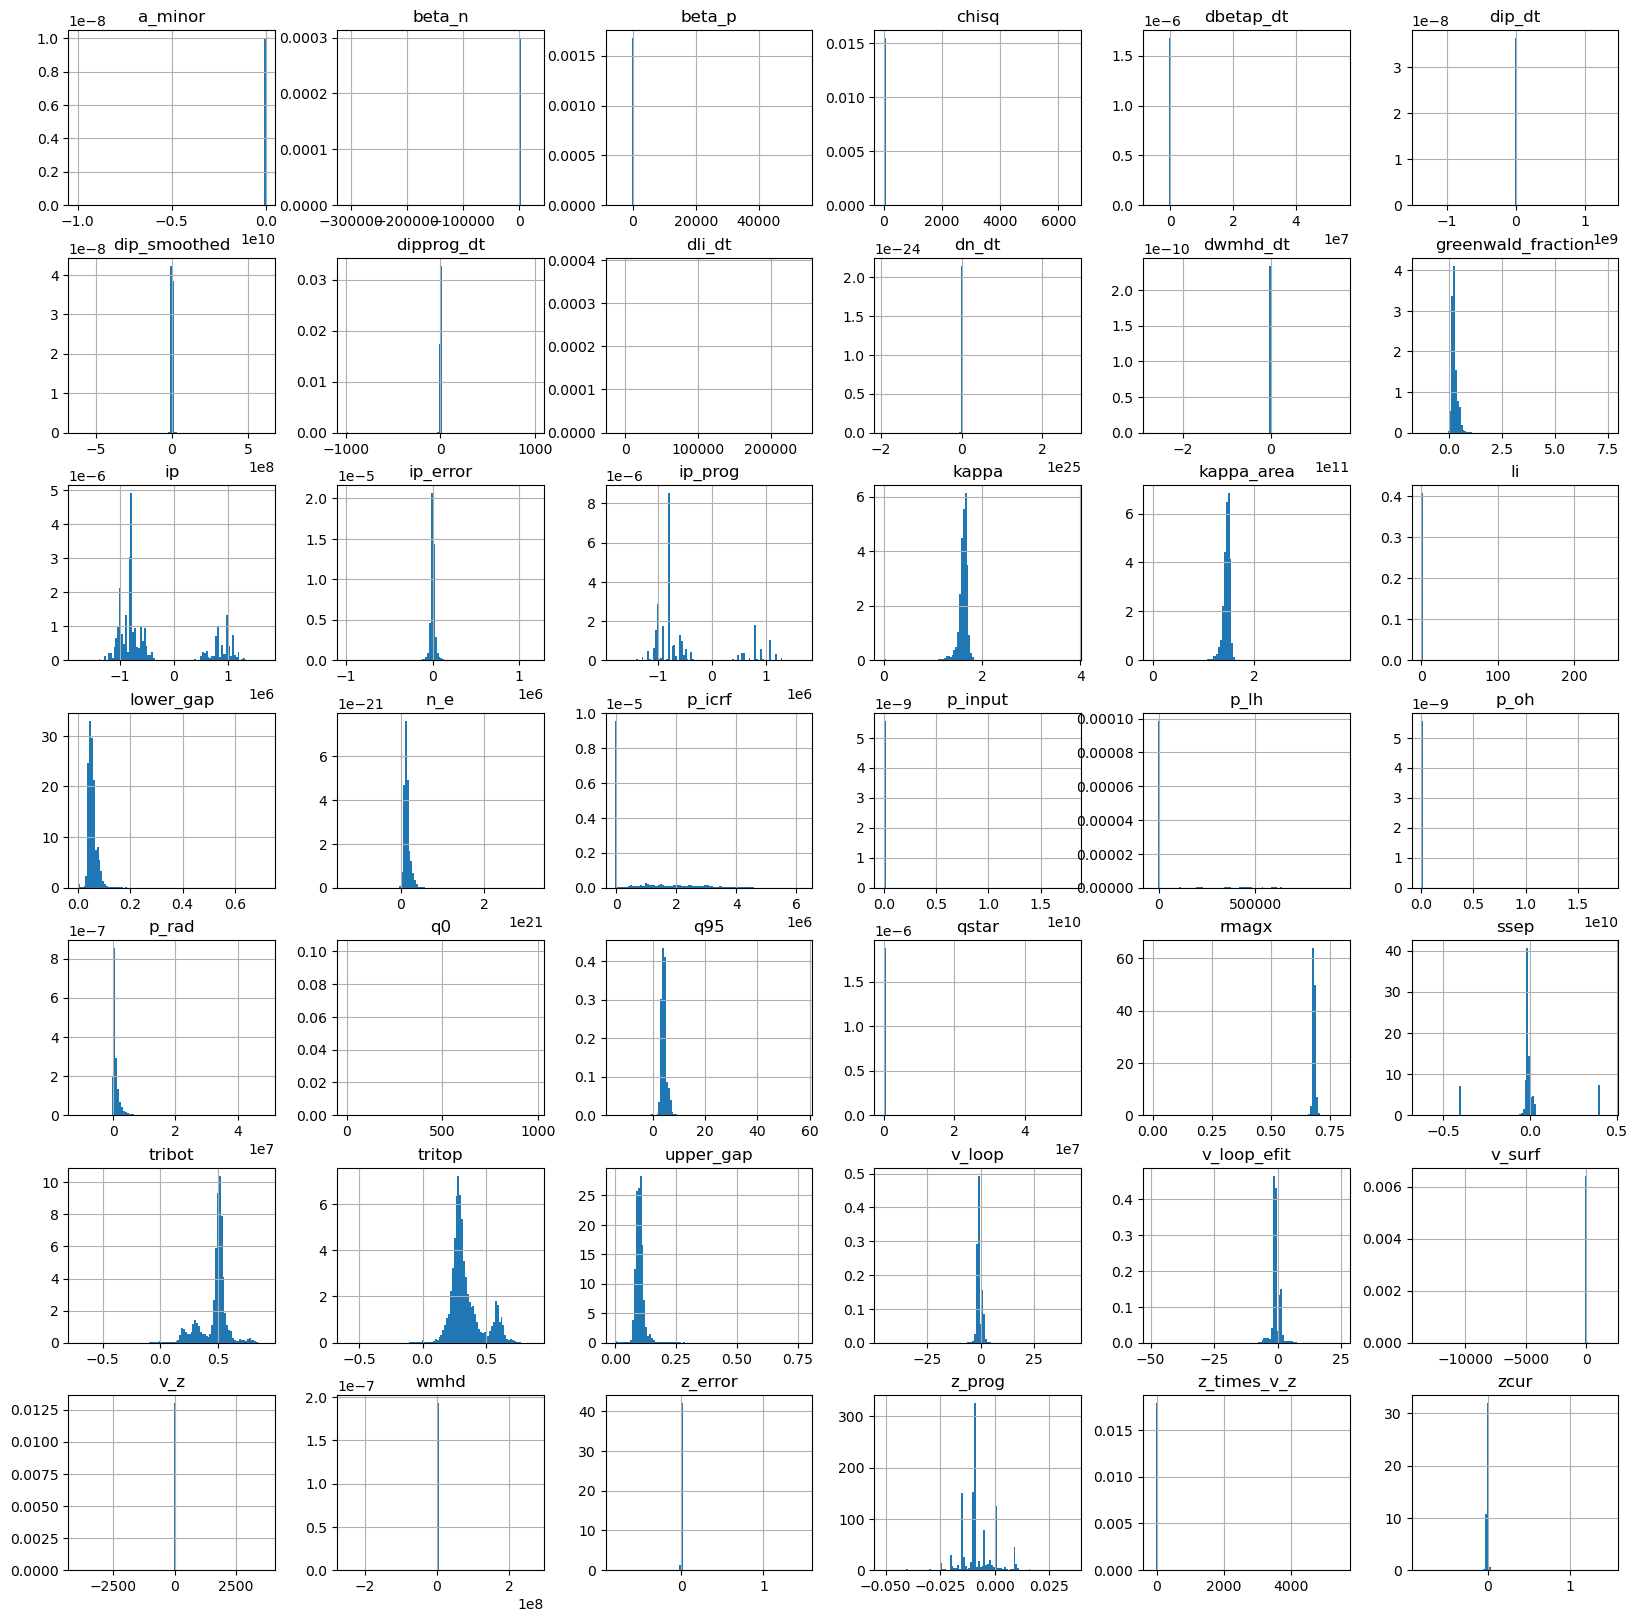

In [23]:
# Flag columns with NaNs and infinities

X = df.drop(['Unnamed: 0', 'shot', 'time', 'disruptive', 'time_until_disrupt'], axis=1)

# drop nans and infinities
shot_filter = X.isna() | X.isin([np.inf, -np.inf])
columns_with_nan_or_inf = X.columns[shot_filter.any()].tolist()

X = X.drop(columns_with_nan_or_inf, axis=1)
#X.head()
X.hist(figsize=(20,20),bins=100,density=True)

In [31]:
y = df['disruptive']

# split into train-test-split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, shuffle=True, stratify=y
)

In [56]:
disrupt_fraction = y.mean()
print(disrupt_fraction) # Use to adjust weighting less infrequent disruptive class

0.08414425815817927


In [65]:
# Train a random forest using XGBoost to predict whether a shot is disruptive or not
models = {
    XGBClassifier(eval_metric="logloss", random_state=42),
    XGBClassifier(eval_metric="logloss", random_state=42, subsample=0.8, scale_pos_weight=(1-disrupt_fraction)/disrupt_fraction),
    XGBClassifier(eval_metric="logloss", random_state=42, max_depth=8)
}
names = ["Standard arguments", "Increased disruption weight", "Deeper tree"]
results = {}

for model, name in zip(models, names):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    preds = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    
    results[name] = (model, train_acc, test_acc, train_time, preds)
    
    print(name)
    print(f"  → Train Accuracy: {train_acc:.3f}")
    print(f"  → Test  Accuracy: {test_acc:.3f}")
    print(f"  → Train Time    : {train_time*1000:.2f} ms\n")



Standard arguments
  → Train Accuracy: 0.971
  → Test  Accuracy: 0.962
  → Train Time    : 1695.31 ms

Increased disruption weight
  → Train Accuracy: 0.991
  → Test  Accuracy: 0.979
  → Train Time    : 2052.63 ms

Deeper tree
  → Train Accuracy: 0.984
  → Test  Accuracy: 0.978
  → Train Time    : 1582.77 ms



Confusion Matrix:
 [[116822   3671]
 [  1328   9742]]


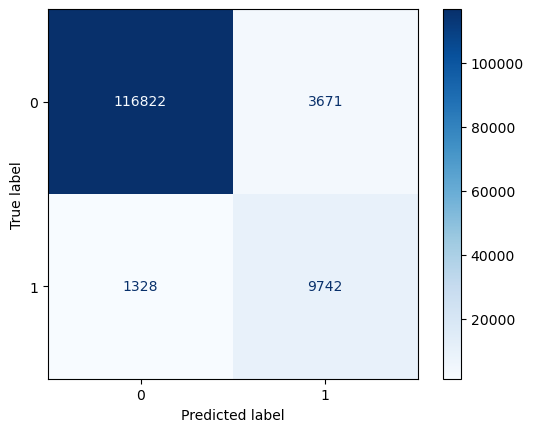

In [59]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report,ConfusionMatrixDisplay

cm = confusion_matrix(y_test, preds)
print("Confusion Matrix:\n", cm)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [60]:
y_true = y_test
predictions = preds
print(classification_report(y_true,predictions.round()))

# Compute metrics
precision = precision_score(y_true, predictions.round())
recall = recall_score(y_true, predictions.round())
f1 = f1_score(y_true, predictions.round())

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

              precision    recall  f1-score   support

           0       0.99      0.97      0.98    120493
           1       0.73      0.88      0.80     11070

    accuracy                           0.96    131563
   macro avg       0.86      0.92      0.89    131563
weighted avg       0.97      0.96      0.96    131563

Precision: 0.7263102959815104
Recall: 0.8800361336946703
F1 Score: 0.7958175060245885


In [55]:
inf_counts = df.isin([np.inf, -np.inf]).sum()
print(inf_counts[inf_counts > 0])

radiated_fraction    1
dtype: int64
